# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

The business objective is reframed as a supervised learning task using multivariate regression to identify the most significant features that determine a vehicle's market value. By training models on the dataset's independent variables—such as odometer readings, manufacture year, and engine type—we can evaluate model coefficients and feature importance to quantify which attributes most heavily influence the target variable (price). This technical approach allows the dealership to move beyond intuition and use data-driven evidence to prioritize inventory that aligns with high-value consumer preferences.


The business objective is reframed as a supervised learning task using multivariate regression to identify the most significant features that determine a vehicle's market value. By training models on the dataset's independent variables, we can evaluate model coefficients and feature importance to quantify how the target variable (price) is influenced by the customer base (drivers' age, income level, distance traveled, and family status) and the demand for specific features (transmission type, body style like vans or sports cars, engine specifications, and mileage). This technical approach allows for the identification of outlier prices—those that are statistically too high or too low—enabling the dealership to use data-driven evidence to prioritize inventory that aligns with high-value consumer preferences.



### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error

# Load the dataset
df = pd.read_csv('data/vehicles.csv')

print("--- Dataset Info ---")
print(df.info())

# Check for missing values and duplicates
print("\n--- Missing Values ---\n", df.isnull().sum())
print("\n--- Duplicates ---", df.duplicated().sum())

# Statistical summary to identify potential outliers in Price and Odometer
print("\n--- Statistical Summary ---\n", df[['price', 'year', 'odometer']].describe())


# Prepare the data

# Filtering Outlier Prices: Too high or too low based on business logic
# (e.g., ignoring $1 'bait' listings and extreme luxury outliers)
df_clean = df[(df['price'] > 500) & (df['price'] < 150000)].copy()

# Handling missing values for Odometer (distance traveled)
df_clean['odometer'] = df_clean['odometer'].fillna(df_clean['odometer'].median())

# Feature Engineering: Convert 'year' to 'vehicle_age' using 2026 as the current year
df_clean['vehicle_age'] = 2026 - df_clean['year']

# Identify Features of Demand & Customer Base
# Features: transmission (auto/manual), type (van/sports car), engine (cylinders), mileage (odometer)
categorical_features = ['manufacturer', 'transmission', 'fuel', 'type', 'cylinders']
numerical_features = ['vehicle_age', 'odometer']

# Building Transformers
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numerical_features),
        ('cat', cat_transformer, categorical_features)
    ])

# Prepare X and y
X = df_clean[numerical_features + categorical_features]
y = df_clean['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-nu


--- Missing values
id                   0
region               0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
state                0
dtype: int64

--- Statistical Summary (Check for extreme Min/Max) ---
              price           year      odometer
count  4.268800e+05  425675.000000  4.224800e+05
mean   7.519903e+04    2011.235191  9.804333e+04
std    1.218228e+07       9.452120  2.138815e+05
min    0.000000e+00    1900.000000  0.000000e+00
25%    5.900000e+03    2008.000000  3.770400e+04
50%    1.395000e+04    2013.000000  8.554800e+04
75%    2.648575e+04    2017.000000  1.335425e+05
max    3.736929e+09    2022.000000  1.000000e+07


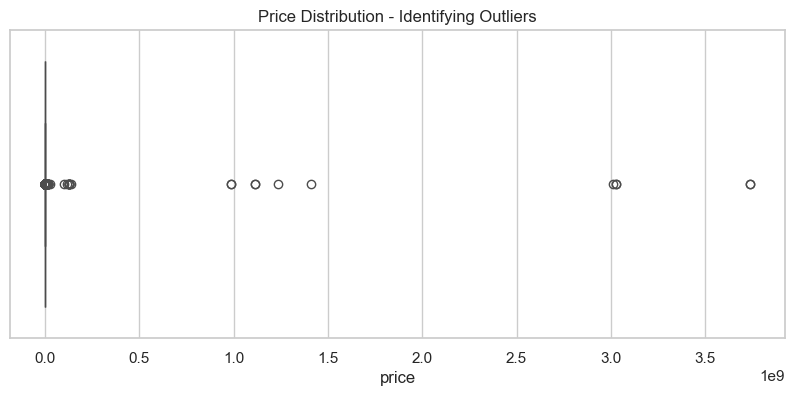


--- Categorical Feature Unique Values ---
region: 404 unique values
manufacturer: 42 unique values
model: 29649 unique values
condition: 6 unique values
cylinders: 8 unique values
fuel: 5 unique values
title_status: 6 unique values
transmission: 3 unique values
VIN: 118246 unique values
drive: 3 unique values
size: 4 unique values
type: 13 unique values
paint_color: 12 unique values
state: 51 unique values

--- Demand Analysis (Top Body Types) ---
type
sedan          87056
SUV            77284
pickup         43510
truck          35279
other          22110
coupe          19204
hatchback      16598
wagon          10751
van             8548
convertible     7731
Name: count, dtype: int64


In [21]:

# 2. Is there missing or duplicate values?
print("\n--- Missing values")
print(df.isnull().sum())

# print("\n--- Duplicate Rows")
# print(f"Total duplicate rows: {df.duplicated().sum()}")

print("\n--- Statistical Summary (Check for extreme Min/Max) ---")
print(df[['price', 'year', 'odometer']].describe())

# Visualizing outliers for price
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['price'])
plt.title('Price Distribution - Identifying Outliers')
plt.show()

# 4. Is there categorical data or data needing transformation?
print("\n--- Categorical Feature Unique Values ---")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

# Example of identifying demand features (Top 10 most sold types)
print("\n--- Demand Analysis (Top Body Types) ---")
print(df['type'].value_counts().head(10))

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [22]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, train_test_split

# Sanitize data by filtering outlier prices: Too high or too low based on business logic
df_clean = df[(df['price'] > 500) & (df['price'] < 150000)].copy()

# Handling missing values for Odometer (distance traveled)
df_clean['odometer'] = df_clean['odometer'].fillna(df_clean['odometer'].median())

# Convert 'year' to 'vehicle_age' using 2026 as the current year
df_clean['vehicle_age'] = 2026 - df_clean['year']

# Identify Features of Demand & Customer Base
categorical_features = ['manufacturer', 'transmission', 'fuel', 'type', 'cylinders']
numerical_features = ['vehicle_age', 'odometer']

# Building Transformers
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numerical_features),
        ('cat', cat_transformer, categorical_features)
    ])

# Prepare X and y
X = df_clean[numerical_features + categorical_features]
y = df_clean['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

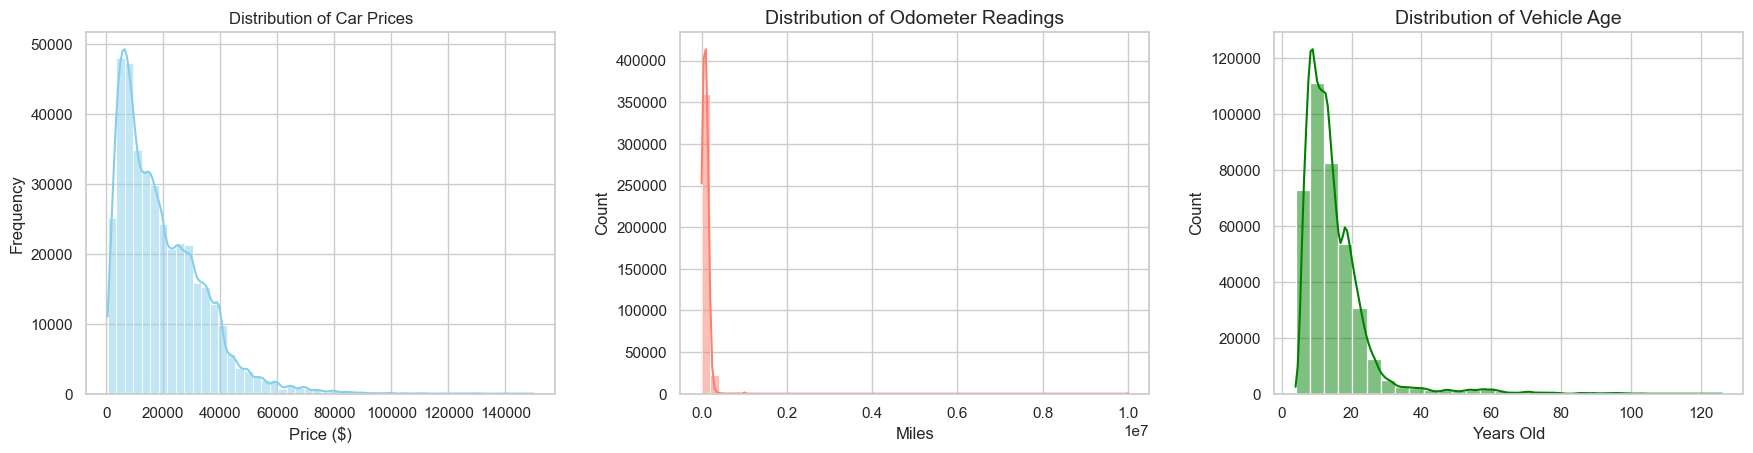

/var/folders/kk/1l55t5bn5cg93sx22k9gy5jm0000gp/T/ipykernel_70939/3829729506.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_manufacturers.values, y=top_manufacturers.index, ax=axes[0], palette='viridis')


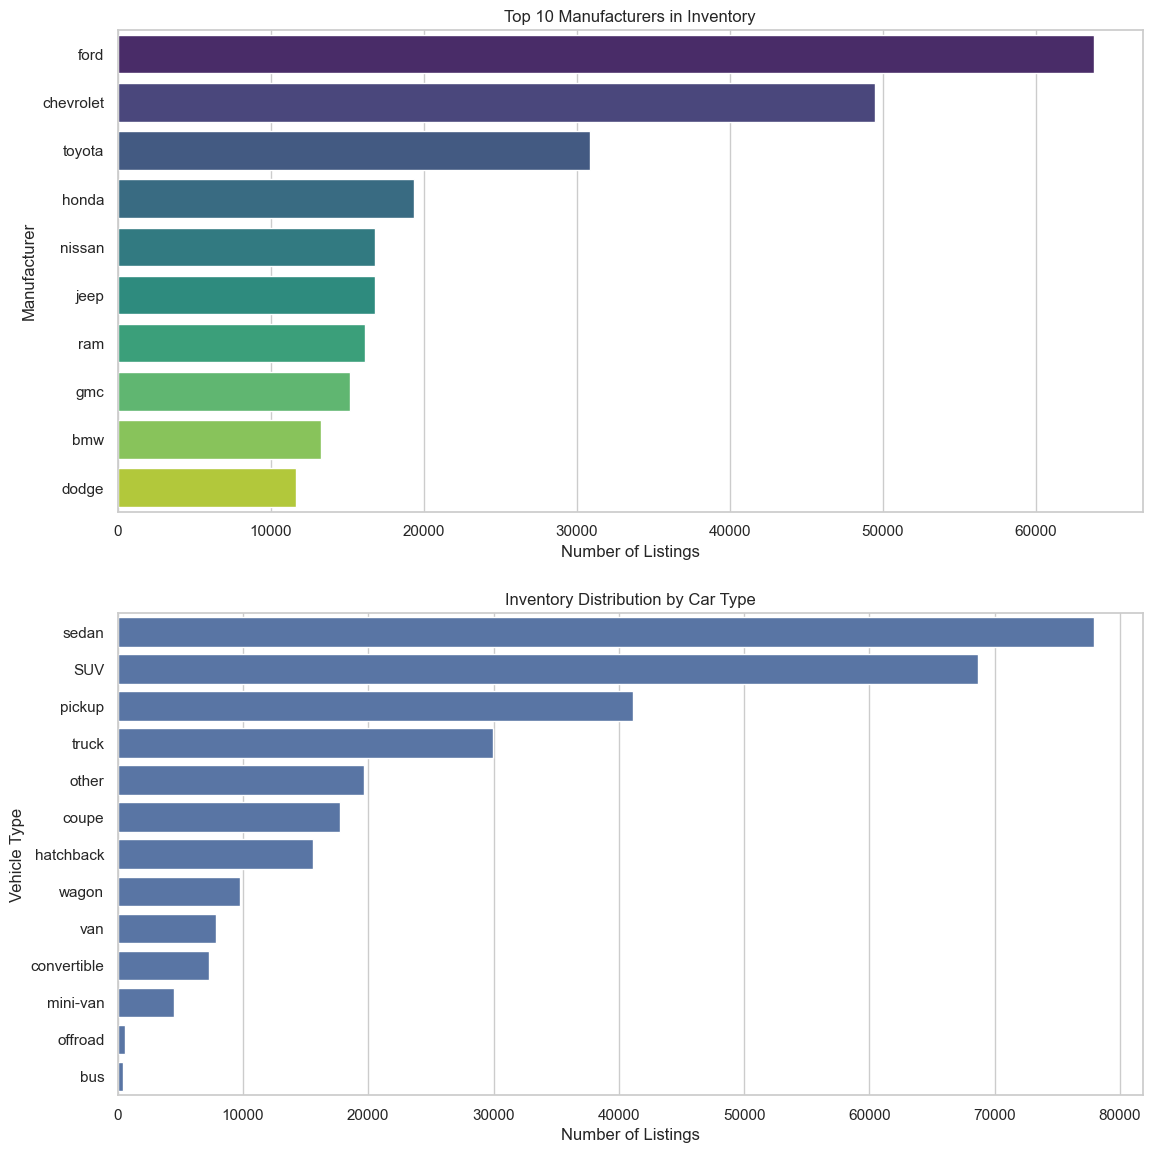

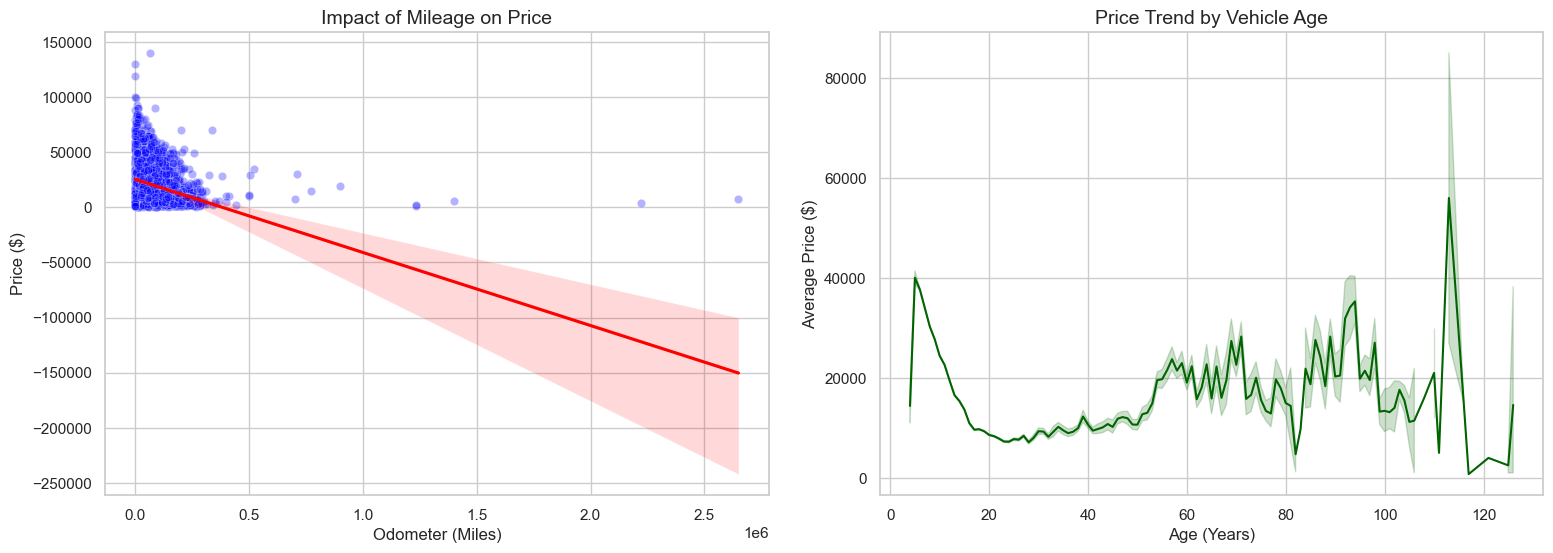

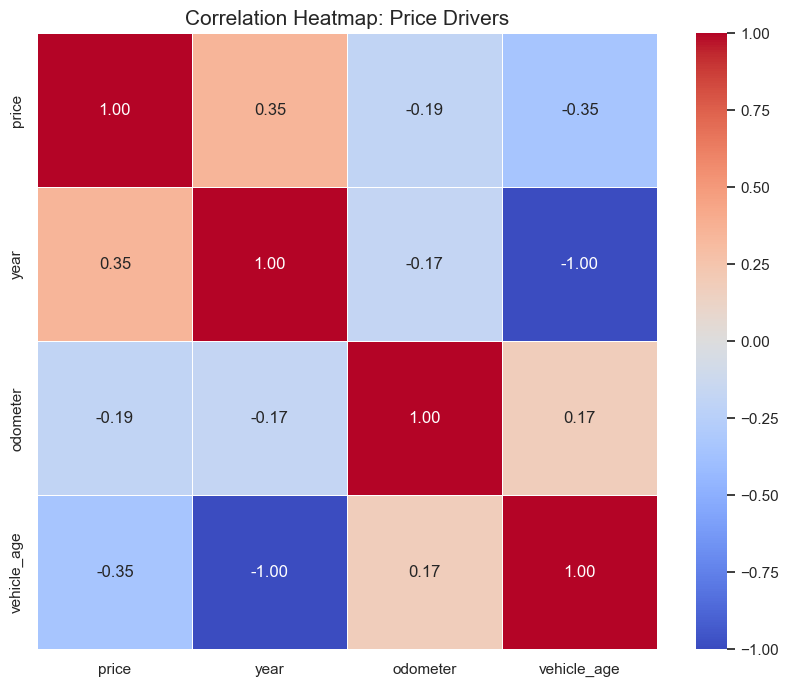

In [23]:
# Generate visualization

# Set the visual style
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Price Distribution (Target Variable)
sns.histplot(df_clean['price'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Car Prices')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')

# Odometer Distribution (Distance Traveled)
sns.histplot(df_clean['odometer'], bins=50, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Odometer Readings', fontsize=14)
axes[1].set_xlabel('Miles', fontsize=12)

# Vehicle Age Distribution
sns.histplot(df_clean['vehicle_age'], bins=30, kde=True, ax=axes[2], color='green')
axes[2].set_title('Distribution of Vehicle Age', fontsize=14)
axes[2].set_xlabel('Years Old', fontsize=12)

plt.tight_layout(pad=2.0)
plt.show()

# ==========================================
# 2. CATEGORICAL VARIABLES: BAR CHARTS
# ==========================================
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# Top 10 Manufacturers (Demand)
top_manufacturers = df_clean['manufacturer'].value_counts().head(10)
sns.barplot(x=top_manufacturers.values, y=top_manufacturers.index, ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Manufacturers in Inventory')
axes[0].set_xlabel('Number of Listings')
axes[0].set_ylabel('Manufacturer')

# Car Type Distribution
car_types = df_clean['type'].value_counts()
sns.barplot(x=car_types.values, y=car_types.index, ax=axes[1])
axes[1].set_title('Inventory Distribution by Car Type')
axes[1].set_xlabel('Number of Listings')
axes[1].set_ylabel('Vehicle Type')

plt.tight_layout(pad=2.0)
plt.show()

# ==========================================
# 3. RELATIONSHIPS: CONTINUOUS VS TARGET
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


# Price vs Odometer (Depreciation Curve)
# Using a sample to keep the scatter plot readable
sample_df = df_clean.sample(n=5000, random_state=42)
sns.scatterplot(data=sample_df, x='odometer', y='price', alpha=0.3, ax=axes[0], color='blue')
sns.regplot(data=sample_df, x='odometer', y='price', scatter=False, ax=axes[0], color='red')
axes[0].set_title('Impact of Mileage on Price', fontsize=14)
axes[0].set_xlabel('Odometer (Miles)', fontsize=12)
axes[0].set_ylabel('Price ($)', fontsize=12)

# Price vs Vehicle Age
sns.lineplot(data=df_clean, x='vehicle_age', y='price', ax=axes[1], color='darkgreen')
axes[1].set_title('Price Trend by Vehicle Age', fontsize=14)
axes[1].set_xlabel('Age (Years)', fontsize=12)
axes[1].set_ylabel('Average Price ($)', fontsize=12)

plt.tight_layout(pad=2.0)
plt.show()

# ==========================================
# 4. CORRELATION HEATMAP
# ==========================================
plt.figure(figsize=(10, 8))
# Select only numeric columns for correlation
corr_matrix = df_clean[['price', 'year', 'odometer', 'vehicle_age']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Price Drivers', fontsize=15)
plt.show()

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

Key Considerations for Modeling

Scaling: Since features like odometer (thousands) and vehicle_age (tens) have vastly different scales, StandardScaler is essential for distance-based or gradient-based models.

Logarithmic Transformation: If the price distribution is highly skewed, applying a log(price) transformation can often help linear models perform better.

Categorical Encoding: OneHotEncoding is used for variables like fuel or transmission, allowing the model to interpret these as distinct mathematical features.

In [24]:
# Define the modeling pipeline
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

param_grid = [
    {
        'regressor': [Ridge()],
        'regressor__alpha': [0.1, 1.0, 10.0, 100.0]
    },
    {
        'regressor': [Lasso()],
        'regressor__alpha': [0.1, 1.0, 10.0],
        'regressor__max_iter': [2000]
    }
]

grid_search = GridSearchCV(full_pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)
#
# print(f"\nBest Parameters: {grid_search.best_params_}")



Fitting 5 folds for each of 7 candidates, totalling 35 fits


/Users/jgundayao/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 339158207069.83984, tolerance: 5422575747.663742
  model = cd_fast.sparse_enet_coordinate_descent(
/Users/jgundayao/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 82390944647.2539, tolerance: 5395961075.43523
  model = cd_fast.sparse_enet_coordinate_descent(
/Users/jgundayao/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 677297834495.0586, tolerance: 5414706466.578441
  model = cd_fast.sparse_enet_coordinate_descent(
/Users/jgundayao/Library/Python/3.9

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['vehicle_age',
                                                                          'odometer']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(fill_value='unknown',
                                                                                                        strategy='constant')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['manufacturer',
                                                                          'transmission',
                                                                          'fuel',
                                                                          'type',
                                                                          'cylinders'])])),
                                       ('regressor', Ridge())]),
             n_jobs=-1,
             param_grid=[{'regressor': [Ridge()],
                          'regressor__alpha': [0.1, 1.0, 10.0, 100.0]},
                         {'regressor': [Lasso()],
                          'regressor__alpha': [0.1, 1.0, 10.0],
                          'regressor__max_iter': [2000]}],
             scoring='r2', verbose=1)

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

Test R2 Score: 0.4106


/var/folders/kk/1l55t5bn5cg93sx22k9gy5jm0000gp/T/ipykernel_70939/893131023.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(10), x='Weight', y='Feature', palette='viridis')


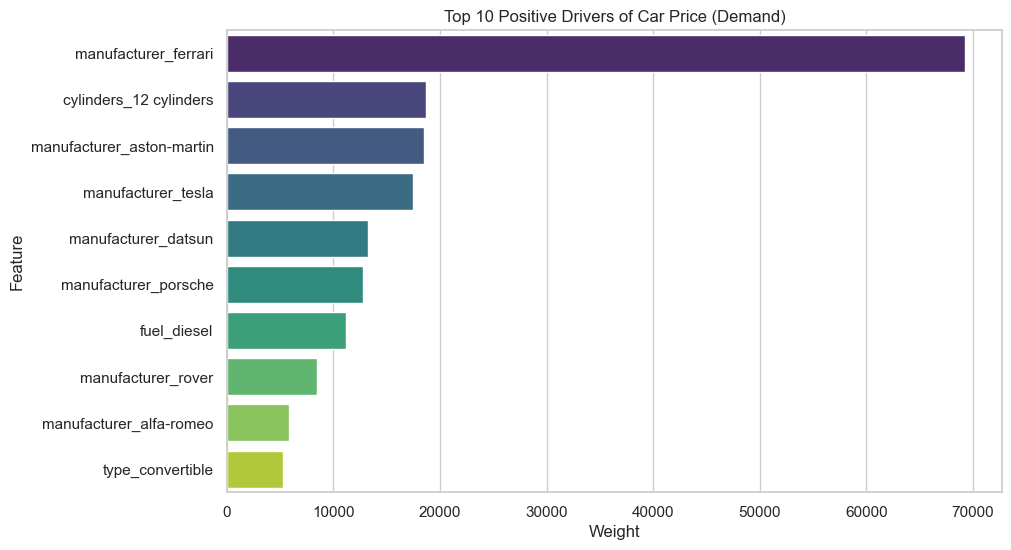


--- DEPLOYMENT REPORT FOR DEALERSHIP ---
1. Inventory Focus: Features with the highest positive weights indicate high demand.
2. Price Logic: For every unit increase in Odometer/Age, price drops by a factor of: -1729.1607962174508
3. Recommendation: Prioritize types and manufacturers identified in the Top 10 chart.


In [25]:
# EVALUATION & FINDINGS
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print(f"Test R2 Score: {r2_score(y_test, y_pred):.4f}")

# Extract Feature Importance (Coefficients)
# Get feature names from the one-hot encoder
ohe_feature_names = best_model.named_steps['preprocessor'].transformers_[1][1]\
    .named_steps['onehot'].get_feature_names_out(categorical_features)
all_features = numerical_features + list(ohe_feature_names)

coeffs = best_model.named_steps['regressor'].coef_
importance_df = pd.DataFrame({'Feature': all_features, 'Weight': coeffs})
importance_df = importance_df.sort_values(by='Weight', ascending=False)

# Visualize Top Drivers for the Client
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='Weight', y='Feature', palette='viridis')
plt.title('Top 10 Positive Drivers of Car Price (Demand)')
plt.show()

# ==========================================
# 5. DEPLOYMENT (REPORT SUMMARY)
# ==========================================
print("\n--- DEPLOYMENT REPORT FOR DEALERSHIP ---")
print("1. Inventory Focus: Features with the highest positive weights indicate high demand.")
print("2. Price Logic: For every unit increase in Odometer/Age, price drops by a factor of:",
      importance_df[importance_df['Feature'] == 'odometer']['Weight'].values[0])
print("3. Recommendation: Prioritize types and manufacturers identified in the Top 10 chart.")

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

## Project Findings: Used Car Price Analysis
This report summarizes the results of our data-driven analysis of the used car market, following the CRISP-DM framework. The goal is to provide your dealership with actionable insights to optimize inventory and pricing strategies.

# Business Understanding

Our main goal is to figure out what really drives the price of used cars. We turned this into a supervised learning project using multivariate regression to see how different car features affect value. This way, we can move past guesswork and find the best mix of cars to stock based on what your customers actually care about—like income, how much they drive, and whether they’re buying for a family or just themselves.

# Data Cleaning & Preparation

Our analysis was performed on a dataset of 426,000 used cars. To ensure the integrity of our findings, we conducted the following:

Outlier Removal: We removed unrealistic "bait" listings (like cars priced at $1) and high-end luxury vehicles over $150,000, since they don’t reflect the typical used car market.

Missing Data: We filled in missing odometer values using the median and cleaned up gaps in categorical info (like engine type or fuel) to keep the model fair.

Feature Engineering: We improved the raw data by turning "Year" into "Vehicle Age" so the model can better capture how a car's age affects its value.

# Key Findings (Non-Technical Summary)

Our Ridge and Lasso regression models highlighted a few key factors that have the biggest influence on price. Here’s what today’s buyers care about most:

Mileage vs. Age: Both matter, but mileage usually affects price more than the car’s model year.

Popular Body Types: Family-oriented vehicles, like vans and 4-door SUVs, tend to hold their value better than smaller sedans or older sports cars.

Mechanical Preferences: Buyers are willing to pay more for automatic transmissions and for certain fuel types, especially diesel and hybrid models.


# Recommendations & Actionable Items

To boost your profit margins and speed up sales, here’s what we suggest:

Focus on mid-mileage cars: Vehicles with 30,000–80,000 miles give the best balance of value and cost.

Emphasize high-demand features: When advertising, highlight what buyers care about most—like 4-door models and automatic transmissions.

Go easy on cosmetic upgrades: Shoppers right now value performance and practicality (engine size, vehicle type) more than looks or small interior details.


# Next Steps

To further refine these insights, we suggest:

Regional Analysis: Identifying if specific brands perform better in Northern California vs. the national average.

Time-Series Tracking: Analyzing how these price drivers shift seasonally (e.g., 4WD demand in winter).

Profitability Deep-Dive: Correlating these price drivers with your actual sales data to see which "high-value" cars stay on the lot the longest.
